# Pet Finder - Adopción de Mascotas

PetFinder.es una plataforma de adopción de Mascotas de Malasia, con una base de datos de más de 150.000 animales. 

Las tasas de adopción de animales están fuertemente correlacionadas con los metadatos asociados con sus perfiles en línea, como el texto descriptivo y las características de las fotografías. Como ejemplo, PetFinder está experimentando actualmente con una herramienta de inteligencia artificial simple llamada Cuteness Meter, que clasifica qué tan linda es una mascota en función de las cualidades presentes en sus fotos.

En esta competencia, desarrollará algoritmos para predecir la adoptabilidad de las mascotas, específicamente, ¿qué tan rápido se adopta una mascota?

Web Organización: https://www.petfinder.my/

Datos: https://www.kaggle.com/c/petfinder-adoption-prediction



## Script Inicial - Análisis Exploratorio

En este trabajo se busca predecir la velocidad a la que se adopta una mascota, según la lista de la mascota en PetFinder. 

A veces, un perfil representa a un grupo de mascotas. En este caso, la velocidad de adopción está determinada por la velocidad a la que se adoptan todas las mascotas. 

Los datos incluyen datos de **Texto Libre**, **Datos Tabulares** e **Emágenes**, lo que lo hace un dataset sumamente rico para explorar

### Ejemplos de Scripts de EDA (Exploratory Data Analysis)

* En R: https://www.kaggle.com/jaseziv83/an-extensive-eda-of-petfinder-my-data
* En Python: https://www.kaggle.com/artgor/exploration-of-data-step-by-step

File descriptions:

* train.csv - Tabular/text data for the training set
* test.csv - Tabular/text data for the test set
* sample_submission.csv - A sample submission file in the correct format
* breed_labels.csv - Contains Type, and BreedName for each BreedID. Type 1 is dog, 2 is cat.
* color_labels.csv - Contains ColorName for each ColorID
* state_labels.csv - Contains StateName for each StateID

In [13]:
conda install numpy pandas matplotlib seaborn wordcloud

3 channel Terms of Service accepted
Channels:
 - defaults
Platform: win-64
Solving environment: done

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [14]:
# Importación de Librerías
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
from wordcloud import WordCloud

%matplotlib inline
pd.set_option('display.max_columns', 30)
plt.rcParams['figure.figsize'] = [12.0, 8.0]

In [15]:
# Datos Tabulares
train = pd.read_csv('../input/petfinder-adoption-prediction/train/train.csv')

In [16]:
train.shape

(14993, 24)

In [17]:
train.head() 

,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed
0,2,Nibble,3,299,0,1,1,7,0,1,1,2,2,2,1,1,100,41326,8480853f516546f6cf33aa88cd76c379,0,Nibble is a 3+ month old ball of cuteness. He ...,86e1089a3,1.0,2
1,2,No Name Yet,1,265,0,1,1,2,0,2,2,3,3,3,1,1,0,41401,3082c7125d8fb66f7dd4bff4192c8b14,0,I just found it alone yesterday near my apartm...,6296e909a,2.0,0
2,1,Brisco,1,307,0,1,2,7,0,2,2,1,1,2,1,1,0,41326,fa90fa5b1ee11c86938398b60abc32cb,0,Their pregnant mother was dumped by her irresp...,3422e4906,7.0,3
3,1,Miko,4,307,0,2,1,2,0,2,1,1,1,2,1,1,150,41401,9238e4f44c71a75282e62f7136c6b240,0,"Good guard dog, very alert, active, obedience ...",5842f1ff5,8.0,2
4,1,Hunter,1,307,0,1,1,0,0,2,1,2,2,2,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,This handsome yet cute boy is up for adoption....,850a43f90,3.0,2


### Data Fields

* PetID - Unique hash ID of pet profile
* AdoptionSpeed - Categorical speed of adoption. Lower is faster. This is the value to predict. See below section for more info.
* Type - Type of animal (1 = Dog, 2 = Cat)
* Name - Name of pet (Empty if not named)
* Age - Age of pet when listed, in months
* Breed1 - Primary breed of pet (Refer to BreedLabels dictionary)
* Breed2 - Secondary breed of pet, if pet is of mixed breed (Refer to BreedLabels dictionary)
* Gender - Gender of pet (1 = Male, 2 = Female, 3 = Mixed, if profile represents group of pets)
* Color1 - Color 1 of pet (Refer to ColorLabels dictionary)
* Color2 - Color 2 of pet (Refer to ColorLabels dictionary)
* Color3 - Color 3 of pet (Refer to ColorLabels dictionary)
* MaturitySize - Size at maturity (1 = Small, 2 = Medium, 3 = Large, 4 = Extra Large, 0 = Not Specified)
* FurLength - Fur length (1 = Short, 2 = Medium, 3 = Long, 0 = Not Specified)
* Vaccinated - Pet has been vaccinated (1 = Yes, 2 = No, 3 = Not Sure)
* Dewormed - Pet has been dewormed (1 = Yes, 2 = No, 3 = Not Sure)
* Sterilized - Pet has been spayed / neutered (1 = Yes, 2 = No, 3 = Not Sure)
* Health - Health Condition (1 = Healthy, 2 = Minor Injury, 3 = Serious Injury, 0 = Not Specified)
* Quantity - Number of pets represented in profile
* Fee - Adoption fee (0 = Free)
* State - State location in Malaysia (Refer to StateLabels dictionary)
* RescuerID - Unique hash ID of rescuer
* VideoAmt - Total uploaded videos for this pet
* PhotoAmt - Total uploaded photos for this pet
* Description - Profile write-up for this pet. The primary language used is English, with some in Malay or Chinese.

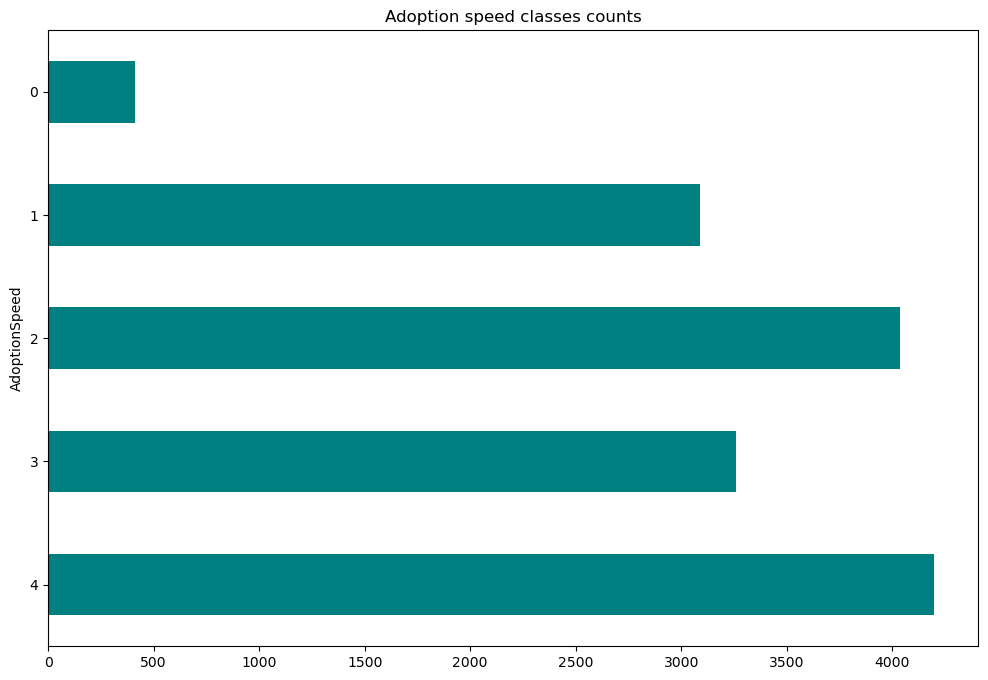

In [18]:
train['AdoptionSpeed'].value_counts().sort_index(ascending = False).plot(kind='barh', color='teal');
plt.title('Adoption speed classes counts');

### Data Fields

* PetID - Unique hash ID of pet profile
* AdoptionSpeed - Categorical speed of adoption. Lower is faster. This is the value to predict. See below section for more info.
* Type - Type of animal (1 = Dog, 2 = Cat)
* Name - Name of pet (Empty if not named)
* Age - Age of pet when listed, in months
* Breed1 - Primary breed of pet (Refer to BreedLabels dictionary)
* Breed2 - Secondary breed of pet, if pet is of mixed breed (Refer to BreedLabels dictionary)
* Gender - Gender of pet (1 = Male, 2 = Female, 3 = Mixed, if profile represents group of pets)
* Color1 - Color 1 of pet (Refer to ColorLabels dictionary)
* Color2 - Color 2 of pet (Refer to ColorLabels dictionary)
* Color3 - Color 3 of pet (Refer to ColorLabels dictionary)
* MaturitySize - Size at maturity (1 = Small, 2 = Medium, 3 = Large, 4 = Extra Large, 0 = Not Specified)
* FurLength - Fur length (1 = Short, 2 = Medium, 3 = Long, 0 = Not Specified)
* Vaccinated - Pet has been vaccinated (1 = Yes, 2 = No, 3 = Not Sure)
* Dewormed - Pet has been dewormed (1 = Yes, 2 = No, 3 = Not Sure)
* Sterilized - Pet has been spayed / neutered (1 = Yes, 2 = No, 3 = Not Sure)
* Health - Health Condition (1 = Healthy, 2 = Minor Injury, 3 = Serious Injury, 0 = Not Specified)
* Quantity - Number of pets represented in profile
* Fee - Adoption fee (0 = Free)
* State - State location in Malaysia (Refer to StateLabels dictionary)
* RescuerID - Unique hash ID of rescuer
* VideoAmt - Total uploaded videos for this pet
* PhotoAmt - Total uploaded photos for this pet
* Description - Profile write-up for this pet. The primary language used is English, with some in Malay or Chinese.

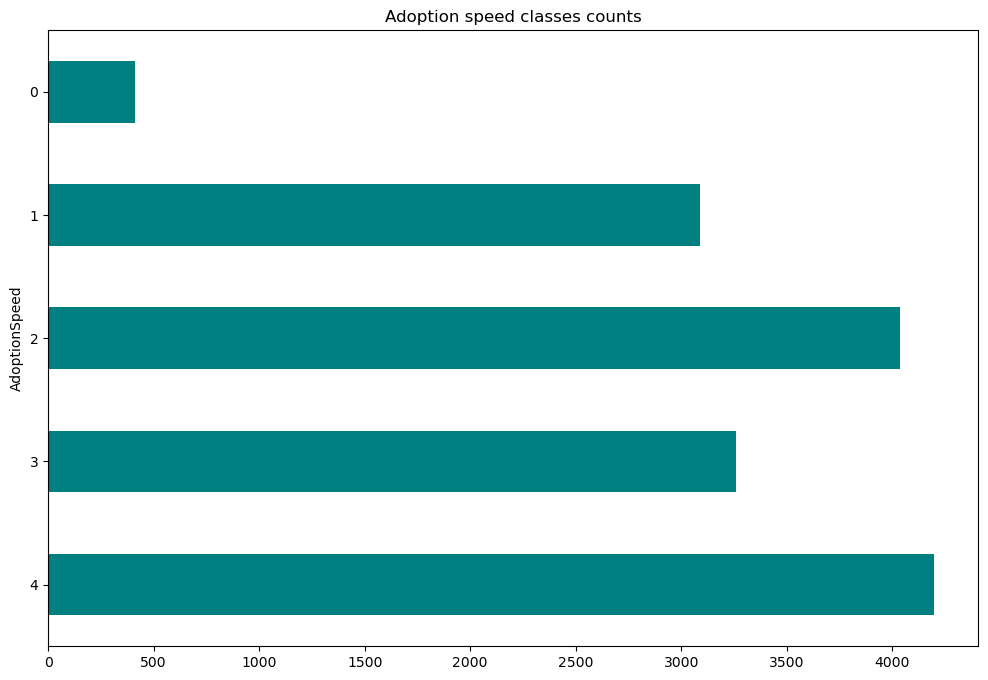

In [19]:
train['AdoptionSpeed'].value_counts().sort_index(ascending = False).plot(kind='barh', color='teal');
plt.title('Adoption speed classes counts');

### Target: AdoptionSpeed

The value is determined by how quickly, if at all, a pet is adopted. The values are determined in the following way:

* 0 - Pet was adopted on the same day as it was listed.
* 1 - Pet was adopted between 1 and 7 days (1st week) after being listed.
* 2 - Pet was adopted between 8 and 30 days (1st month) after being listed.
* 3 - Pet was adopted between 31 and 90 days (2nd & 3rd month) after being listed.
* 4 - No adoption after 100 days of being listed. (There are no pets in this dataset that waited between 90 and 100 days).

In [20]:
# Mapeamos el Tipo de Mascota
train['Type'] = train['Type'].apply(lambda x: 'Dog' if x == 1 else 'Cat')

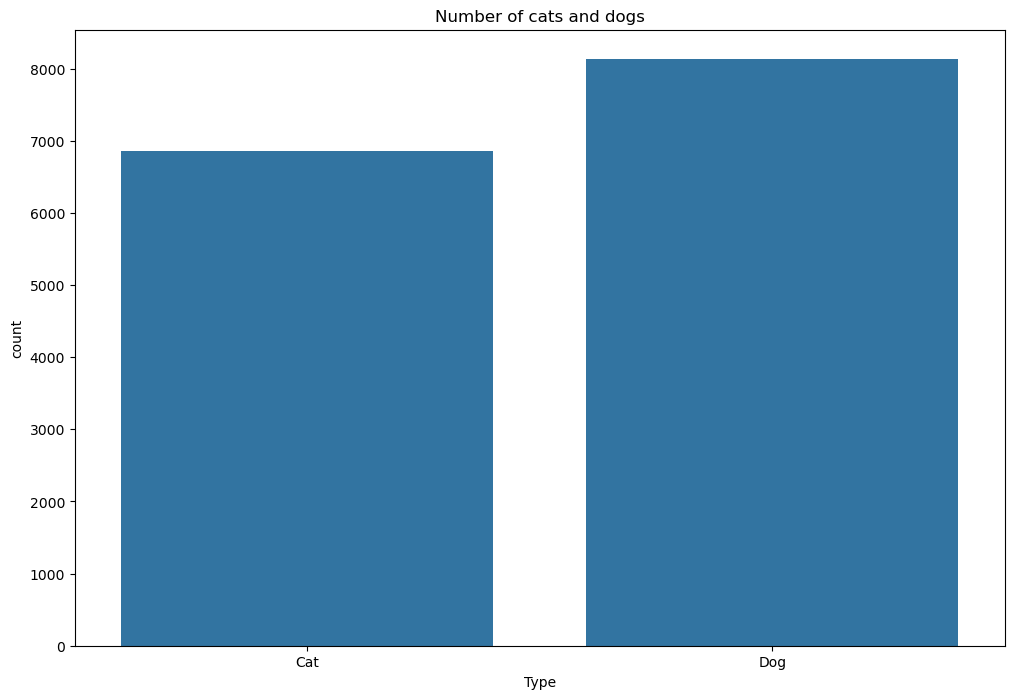

In [21]:
sns.countplot(x='Type', data=train);
plt.title('Number of cats and dogs');

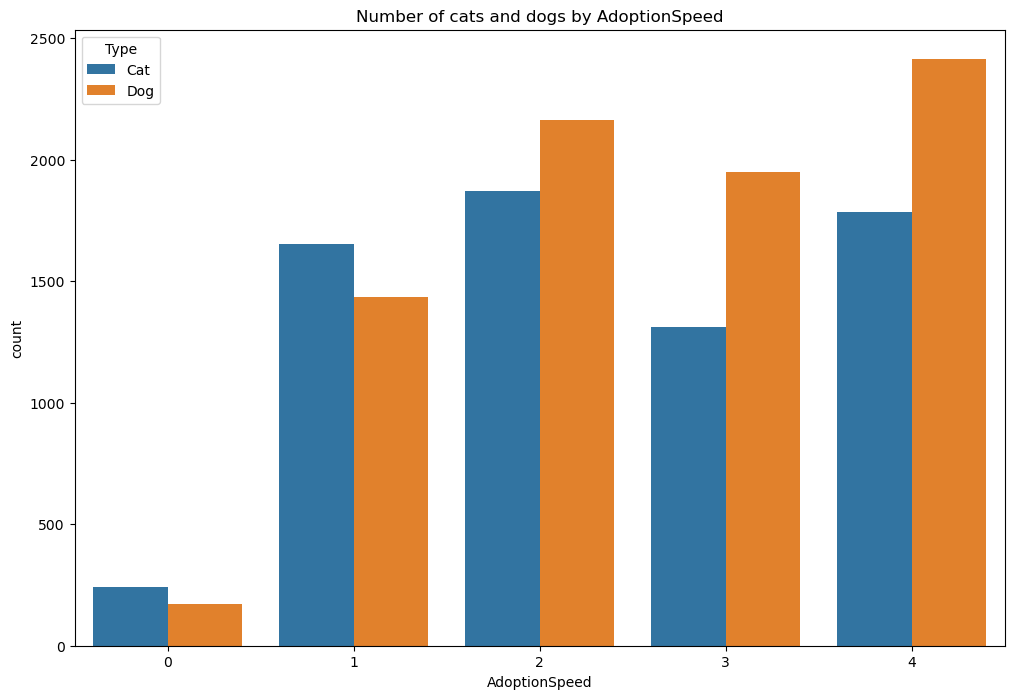

In [22]:
sns.countplot(x='AdoptionSpeed', data=train, hue='Type');
plt.title('Number of cats and dogs by AdoptionSpeed');

In [23]:
train.Name.value_counts()

Name
Baby                                   66
Lucky                                  64
Brownie                                54
No Name                                54
Mimi                                   52
                                       ..
Pets + Strays : BlueEyed BlackWhite     1
Serato & Eddie                          1
Monkies                                 1
Ms Daym                                 1
Fili                                    1
Name: count, Length: 9059, dtype: int64

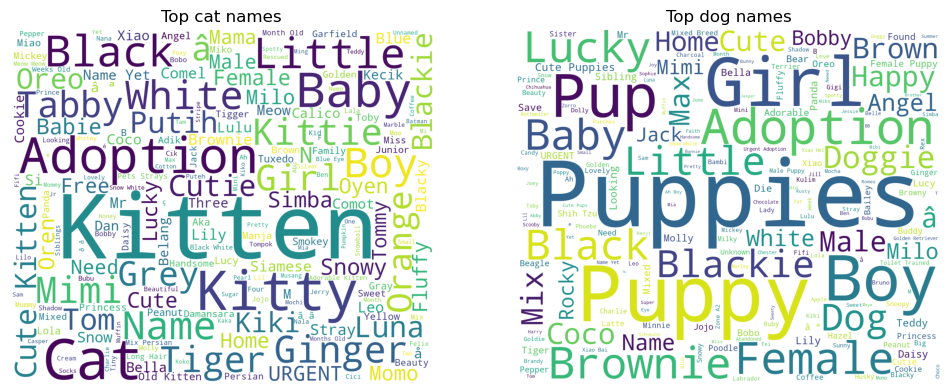

In [24]:
plt.subplot(1, 2, 1)
text_cat = ' '.join(train.loc[train['Type'] == 'Cat', 'Name'].fillna('').values)
wordcloud = WordCloud(max_font_size=None, background_color='white',
                      width=1200, height=1000).generate(text_cat)
plt.imshow(wordcloud)
plt.title('Top cat names')
plt.axis("off")

plt.subplot(1, 2, 2)
text_dog = ' '.join(train.loc[train['Type'] == 'Dog', 'Name'].fillna('').values)
wordcloud = WordCloud(max_font_size=None, background_color='white',
                      width=1200, height=1000).generate(text_dog)
plt.imshow(wordcloud)
plt.title('Top dog names')
plt.axis("off")

plt.show()

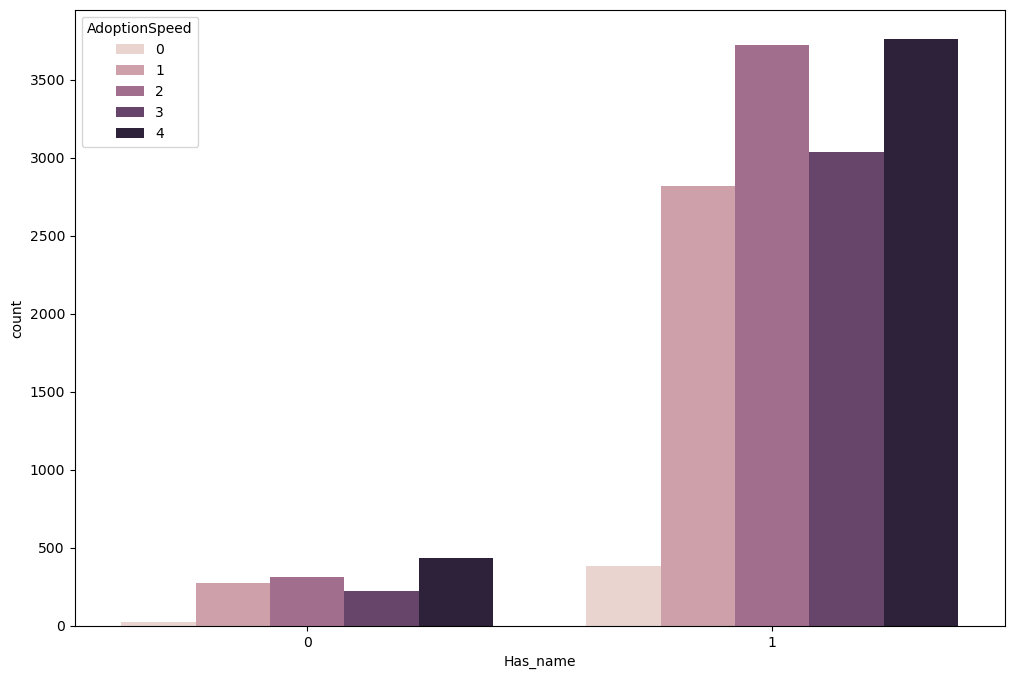

In [25]:
train['Name'] = train['Name'].fillna('Unnamed')
train['Has_name'] = 1
train.loc[train['Name'] == 'Unnamed', 'Has_name'] = 0

sns.countplot(x='Has_name', data=train, hue='AdoptionSpeed');

Text(0.5, 1.0, 'Distribution of pets age in Months')

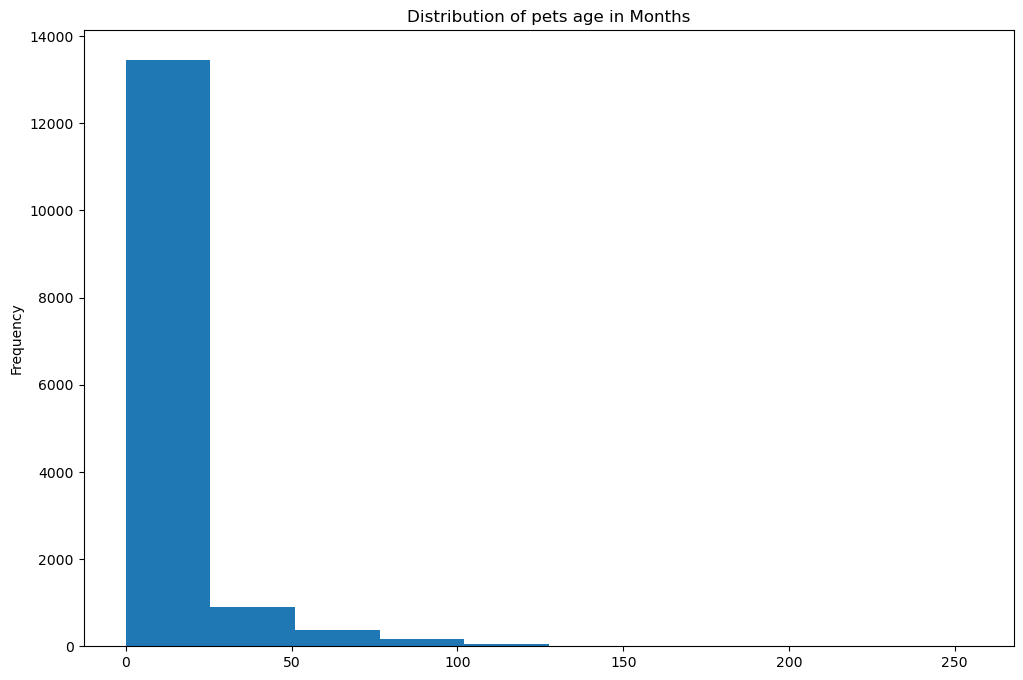

In [26]:
train['Age'].plot(kind='hist')
plt.title('Distribution of pets age in Months')

## Tareas a Realizar

#### Pre-procesamiento:

* Chequear Nulos y Decidir si Imputar o Descartar
* Chequear Variables Categóricas y convertirlas en Numéricas
* Estandarizar o Normalizar

#### Ideas para EDA:

* Analizar la Raza de las Mascotas
* Analizar el Género
* Analizar los 3 Colores Informados para cada Mascota
* Estudiar las variables de Salud: Vacunación, Esterilización, Desparacitación
* Entender el impacto del Fee cobrado
* Estudiar las Regiones Geográficas disponibles
* Analizar el impacto de tener Fotos y/o Videos

Todos estos análisis pueden hacerse en función de la Especie (Gato/Perro) y respecto al Target



In [30]:
#chequear nulos
# Ver nulos
train.isnull().sum().sort_values(ascending=False)

Description      13
Name              0
Age               0
Breed1            0
Breed2            0
Gender            0
Color1            0
Color2            0
Type              0
Color3            0
MaturitySize      0
Vaccinated        0
FurLength         0
Sterilized        0
Health            0
Quantity          0
Dewormed          0
Fee               0
State             0
RescuerID         0
VideoAmt          0
PetID             0
PhotoAmt          0
AdoptionSpeed     0
Has_name          0
dtype: int64

In [ ]:
# Imputación de valores faltantes:
# - Name: se reemplaza por 'Unnamed' para identificar mascotas sin nombre
# - Description: se completa con string vacío para evitar errores en análisis de texto
# - Age: se completa con la mediana porque representa mejor la edad típica
# y no se ve afectada por valores extremos
# - Fee: se reemplaza por 0 asumiendo adopciones sin costo
train['Name'] = train['Name'].fillna('Unnamed')
train['Description'] = train['Description'].fillna('')
train['Age'] = train['Age'].fillna(train['Age'].median())
train['Fee'] = train['Fee'].fillna(0)

In [32]:

# Se crean nuevas variables a partir de la información original:
# - Has_name: indica si la mascota tiene nombre
# - Desc_length: longitud de la descripción (proxy de calidad del perfil)
# - MediaAmt: cantidad total de contenido multimedia (fotos + videos)

# Tiene nombre
train['Has_name'] = (train['Name'] != 'Unnamed').astype(int)

# Largo descripción
train['Desc_length'] = train['Description'].apply(len)

# Total multimedia
train['MediaAmt'] = train['PhotoAmt'] + train['VideoAmt']

In [ ]:
# Convertimos variables categóricas en variables numéricas (0 y 1)
# para que puedan ser utilizadas en modelos de machine learning

# Tipo
train['Type'] = train['Type'].map({1: 'Dog', 2: 'Cat'})

# One Hot Encoding
cat_cols = ['Type','Gender','MaturitySize','FurLength',
            'Vaccinated','Dewormed','Sterilized','Health']

train = pd.get_dummies(train, columns=cat_cols, drop_first=True)

In [ ]:
# Se eliminan variables no informativas o redundantes:
# - IDs únicos (PetID, RescuerID) que no aportan valor predictivo
# - Variables de texto ya transformadas (Name, Description)
# para reducir dimensionalidad y evitar ruido en el modelo
train = train.drop(['Name','Description','PetID','RescuerID'], axis=1)

<Axes: xlabel='AdoptionSpeed', ylabel='count'>

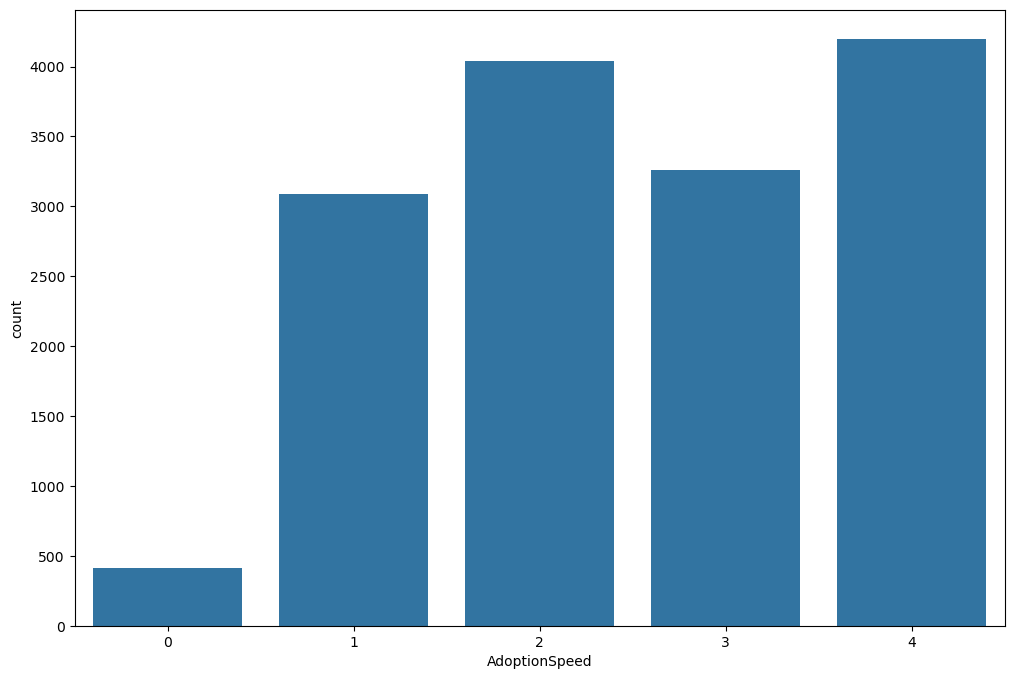

In [ ]:
#EDA
#Distribucion del target
#Cuenta cuántos casos hay de cada valor de AdoptionSpeed
sns.countplot(x='AdoptionSpeed', data=train)

In [ ]:
#EDA
train_eda = train.copy()

<Axes: xlabel='AdoptionSpeed', ylabel='count'>

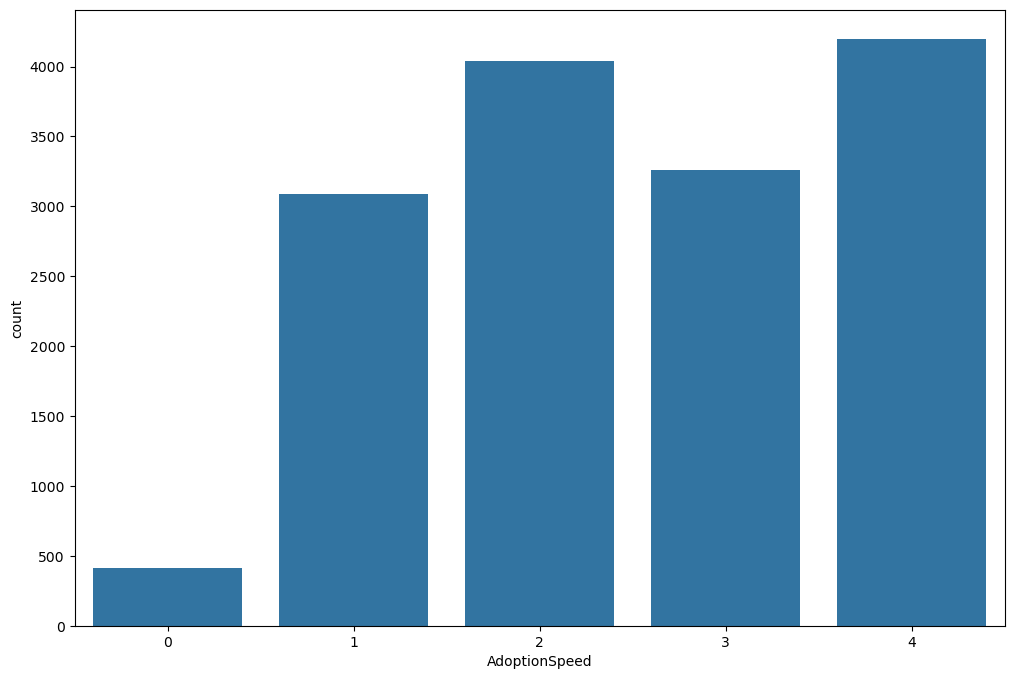

In [ ]:
#Distribucion del target
# cuántos casos hay de cada valor de AdoptionSpeed
sns.countplot(x='AdoptionSpeed', data= train_eda)

<Axes: xlabel='Type', ylabel='count'>

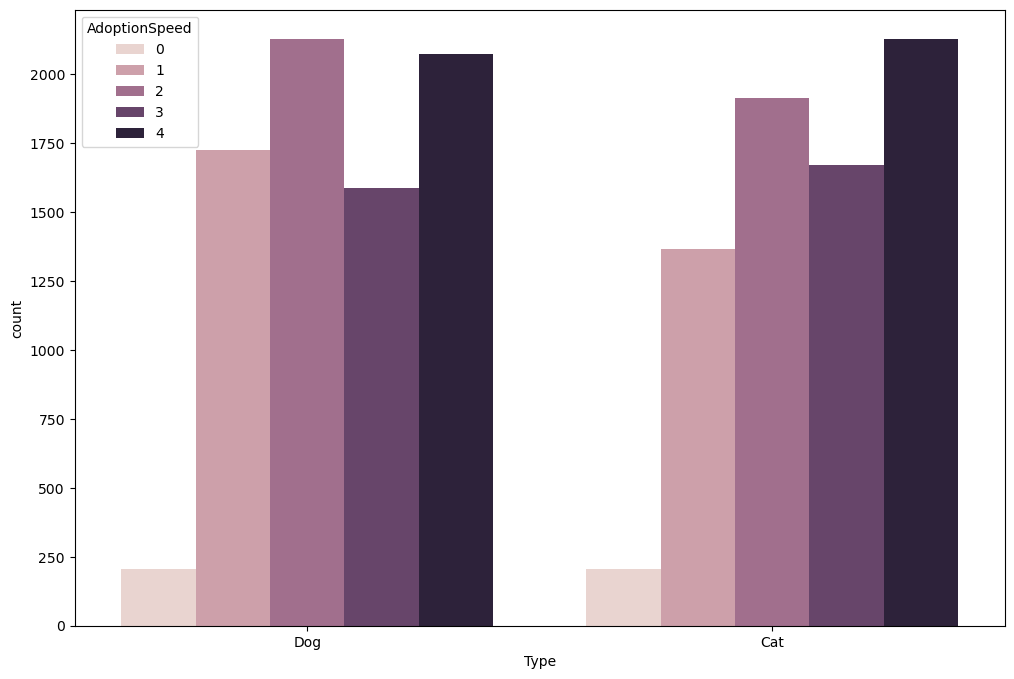

In [55]:

sns.countplot(x='Type', hue='AdoptionSpeed', data=train_eda)

In [57]:
#promedio de adopcion agrupado por raza
train_eda.groupby('Breed1')['AdoptionSpeed'].mean()

Breed1
0      3.200000
1      4.000000
3      4.000000
5      2.500000
7      4.000000
         ...   
303    2.333333
304    2.857143
305    2.875000
306    2.482143
307    2.746077
Name: AdoptionSpeed, Length: 176, dtype: float64

<Axes: xlabel='Gender_2', ylabel='count'>

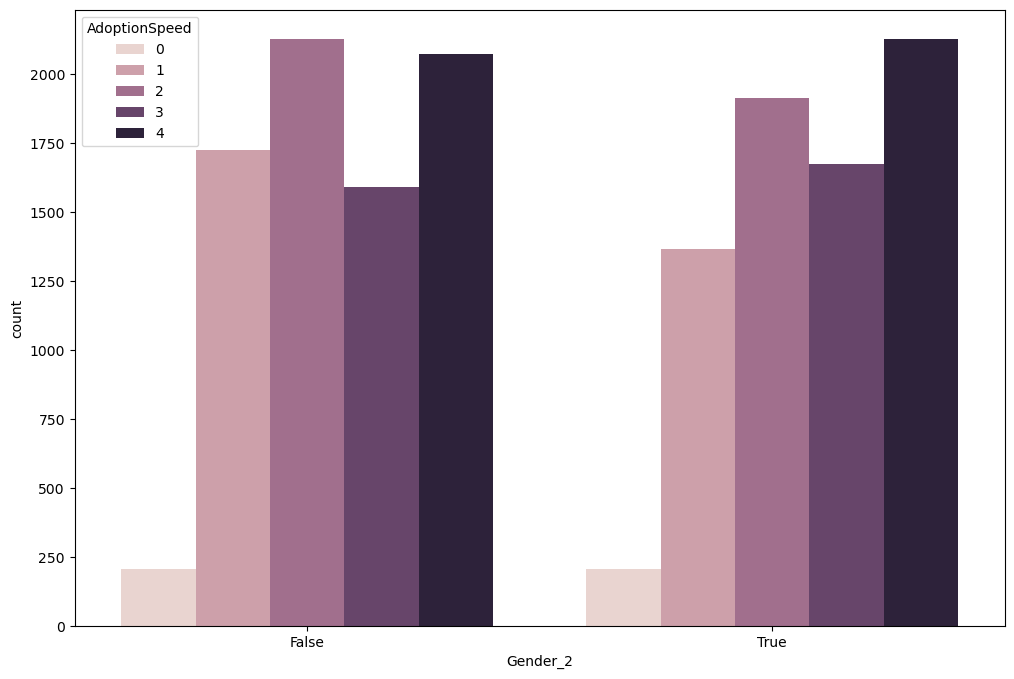

In [ ]:
## Gender fue transformado mediante One Hot Encoding.
# Gender_2 indica si la mascota es hembra (1) o no (0).
# Se analiza su relación con la velocidad de adopción.
sns.countplot(x='Gender_2', hue='AdoptionSpeed', data=train_eda)

In [ ]:
#promedio de adopcion por color
train_eda.groupby('Color1')['AdoptionSpeed'].mean()

Color1
1    2.533594
2    2.584267
3    2.412883
4    2.569401
5    2.351810
6    2.381579
7    2.397301
Name: AdoptionSpeed, dtype: float64

<Axes: xlabel='Health_status', ylabel='count'>

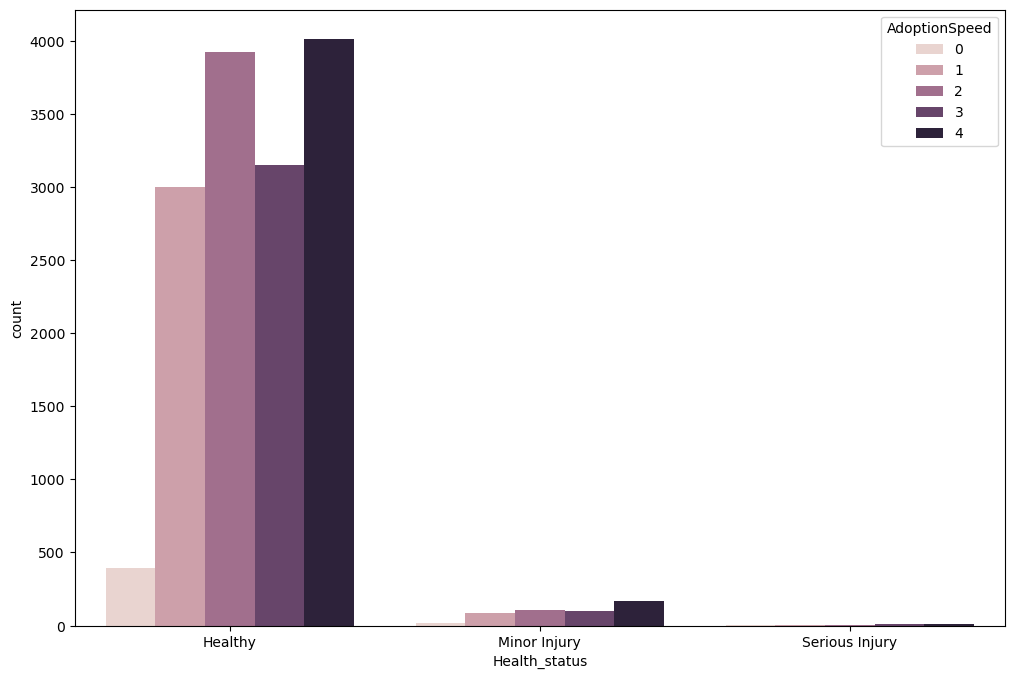

In [ ]:
# Se reconstruye la variable de salud a partir de las variables dummy
# para analizar su impacto en la velocidad de adopción

train_eda['Health_status'] = 'Healthy'
train_eda.loc[train_eda['Health_2'] == 1, 'Health_status'] = 'Minor Injury'
train_eda.loc[train_eda['Health_3'] == 1, 'Health_status'] = 'Serious Injury'
sns.countplot(x='Health_status', hue='AdoptionSpeed', data=train_eda)

<Axes: xlabel='AdoptionSpeed', ylabel='Fee'>

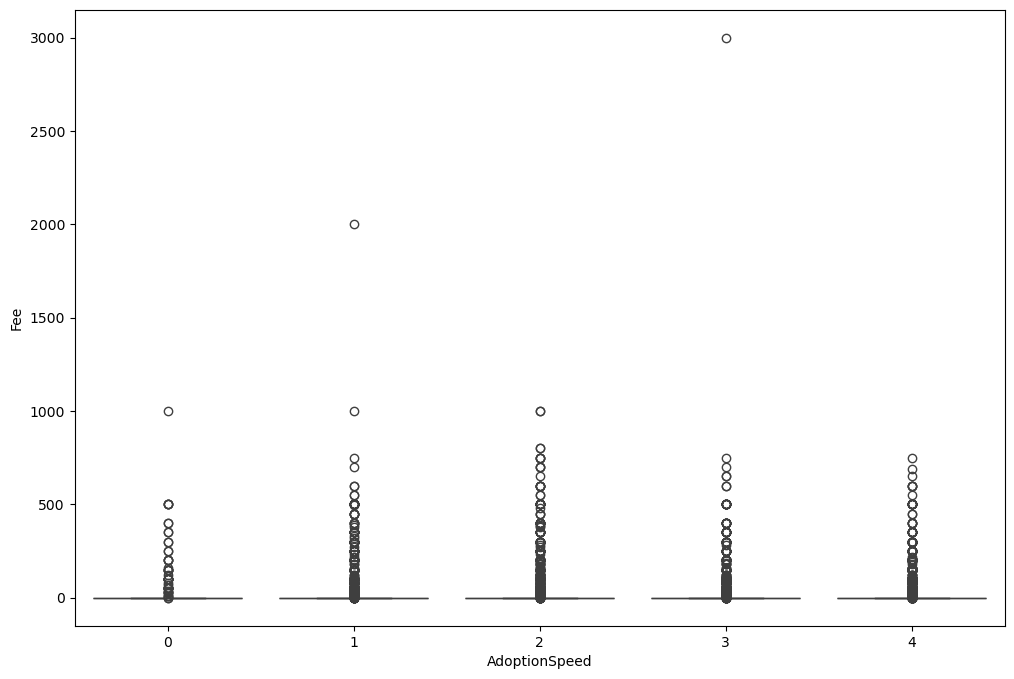

In [ ]:
#distribucion segun precio
sns.boxplot(x='AdoptionSpeed', y='Fee', data=train)

In [ ]:
#promedio de adopcion segun region
train.groupby('State')['AdoptionSpeed'].mean()

State
41324    3.065693
41325    2.681818
41326    2.452031
41327    2.781732
41330    2.821429
41332    2.845850
41335    2.317647
41336    2.410256
41342    3.307692
41345    2.545455
41361    2.576923
41367    2.400000
41401    2.540182
41415    3.000000
Name: AdoptionSpeed, dtype: float64

In [73]:
#Calcula promedio de fotos/videos por clase
train_eda.groupby('AdoptionSpeed')['PhotoAmt'].mean()
train_eda.groupby('AdoptionSpeed')['VideoAmt'].mean()

AdoptionSpeed
0    0.060976
1    0.044984
2    0.063413
3    0.072722
4    0.046223
Name: VideoAmt, dtype: float64

In [ ]:
#EDA
train_eda = train.copy()